# 01 Research Question and Data Preparation

## Project Cycle 3: Gender and Sad or Hopeless Feeling

This notebook prepares the two variables needed for **Question 3** and documents the first data-cleaning step.

**Research question:**  
Is the proportion of students who felt sad or hopeless different between male and female students?

**中文研究問題：**  
男、女學生感到 sad or hopeless 的比例是否不同？

---

### Variables

| Role | Variable | Description | Coding used in this project |
|---|---|---|---|
| Group variable | `WhatIsYourSex` | Student sex | `1 = Female`, `0 = Male` |
| Response variable | `SadOrHopeless` | Whether the student felt sad or hopeless | `1 = Yes`, `0 = No` |

### Hypotheses

\[
H_0: p_{female} = p_{male}
\]

\[
H_1: p_{female} <> p_{male}
\]

where \(p_{female}\) and \(p_{male}\) are the population proportions of female and male students who felt sad or hopeless.


## 1. Import Packages and Set File Paths

This section imports the required packages and defines the input/output paths.  
The original data should be kept in `data/raw/`, while cleaned data and outputs are saved separately.


In [28]:
# Import packages
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# File paths
raw_data_path = Path("../data/raw/YRBS_2007.csv")
processed_dir = Path("../data/processed")
fig_dir = Path("../outputs/figures")
table_dir = Path("../outputs/tables")

# Create output folders if they do not exist
processed_dir.mkdir(parents=True, exist_ok=True)
fig_dir.mkdir(parents=True, exist_ok=True)
table_dir.mkdir(parents=True, exist_ok=True)


## 2. Load the Raw Dataset

The raw dataset is loaded without modifying the original file.


In [29]:
# Load raw data
df = pd.read_csv(raw_data_path)

# Basic information
print("Raw data shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())


Raw data shape: (14041, 103)

Column names:
['RaceEth', 'HowOldAreYou', 'WhatIsYourSex', 'InWhatGradeAreYou', 'AreYouHispanicOrLatino', 'WhatIsYourRace', 'HowTallAreYouWithoutShoesInMeters', 'HowMuchDoYouWeighWithoutShoesInKG', 'BicyleHelmetUse', 'SeatBeltUse', 'RidingWithADrinkingDriver', 'DrinkingAndDriving', 'WeaponCarrying', 'GunCarryingPast12Mos', 'WeaponCarryingAtSchool', 'SafetyConcernsAtSchool', 'WereThreatenedOrInjuredWithAWeaponOnSchoolProperty', 'StolenOrDamagedYourProperty', 'PhysicalFighting', 'InjuredIFight', 'PhysicalFightingAtSchool', 'BoyfriendGirlfriendPhysicallyHurt', 'ForcedSexualIntercourse', 'SadOrHopeless', 'ConsideredSuicide', 'MadeASuicidePlan', 'AttemptedSuicide', 'InjuriousSuicide', 'EverCigaretteUse', 'InitiationSmokingWholeCigarette', 'CurrentCigaretteUse', 'SmokedMoreThan10Cigarettes', 'HowObtainedCigarettes', 'SmokeOnSchoolProperty', 'EverSmokedDailyFor30Days', 'EverSmokingCessation', 'CurrentSmokelessTobaccoUse', 'CurrentSmokelessTobaccoOnSchoolProperty'

## 3. Select Variables for Question 3

Only the two variables needed for this research question are selected:

- `WhatIsYourSex`
- `SadOrHopeless`


In [30]:
# Select variables for Question 3
selected_columns = [
    "WhatIsYourSex",
    "SadOrHopeless"
]

df_selected = df[selected_columns].copy()

print("Selected data shape:", df_selected.shape)
print("\nFirst 5 rows:")
display(df_selected.head())


Selected data shape: (14041, 2)

First 5 rows:


,WhatIsYourSex,SadOrHopeless
0,2.0,1.0
1,2.0,2.0
2,2.0,1.0
3,1.0,1.0
4,1.0,1.0


## 4. Check Original Coding

Before cleaning and recoding, check the original frequency of both variables.  
This helps confirm whether the values follow the expected YRBS coding.


In [31]:
# Frequency tables before cleaning
print("Original frequency: WhatIsYourSex")
display(df_selected["WhatIsYourSex"].value_counts(dropna=False).sort_index())

print("\nOriginal frequency: SadOrHopeless")
display(df_selected["SadOrHopeless"].value_counts(dropna=False).sort_index())


Original frequency: WhatIsYourSex


WhatIsYourSex
1.0    7036
2.0    6992
NaN      13
Name: count, dtype: int64


Original frequency: SadOrHopeless


SadOrHopeless
1.0    4153
2.0    9692
NaN     196
Name: count, dtype: int64

## 5. Missing Value Check

Missing values are classified into four categories:

1. Only missing `WhatIsYourSex`
2. Only missing `SadOrHopeless`
3. Missing both variables
4. Missing neither variable

Only records in the fourth category will be kept for the analysis.


In [32]:
# Missing value conditions
only_missing_sex = (
    df_selected["WhatIsYourSex"].isna()
    & df_selected["SadOrHopeless"].notna()
)

only_missing_sad = (
    df_selected["WhatIsYourSex"].notna()
    & df_selected["SadOrHopeless"].isna()
)

missing_both = (
    df_selected["WhatIsYourSex"].isna()
    & df_selected["SadOrHopeless"].isna()
)

missing_neither = (
    df_selected["WhatIsYourSex"].notna()
    & df_selected["SadOrHopeless"].notna()
)

# Missing value summary table
missing_summary = pd.DataFrame({
    "missing_category": [
        "Only missing WhatIsYourSex",
        "Only missing SadOrHopeless",
        "Missing both variables",
        "Missing neither variable"
    ],
    "count": [
        only_missing_sex.sum(),
        only_missing_sad.sum(),
        missing_both.sum(),
        missing_neither.sum()
    ]
})

missing_summary["percentage"] = (
    missing_summary["count"] / len(df_selected) * 100
).round(2)

print("Missing value summary:")
display(missing_summary)

# Save missing value summary
missing_summary.to_csv(
    table_dir / "cycle3_missing_value_summary.csv",
    index=False
)


Missing value summary:


,missing_category,count,percentage
0,Only missing WhatIsYourSex,12,0.09
1,Only missing SadOrHopeless,195,1.39
2,Missing both variables,1,0.01
3,Missing neither variable,13833,98.52


## 6. Missing Value Pie Chart

The pie chart summarizes the missing-value pattern for the two selected variables.


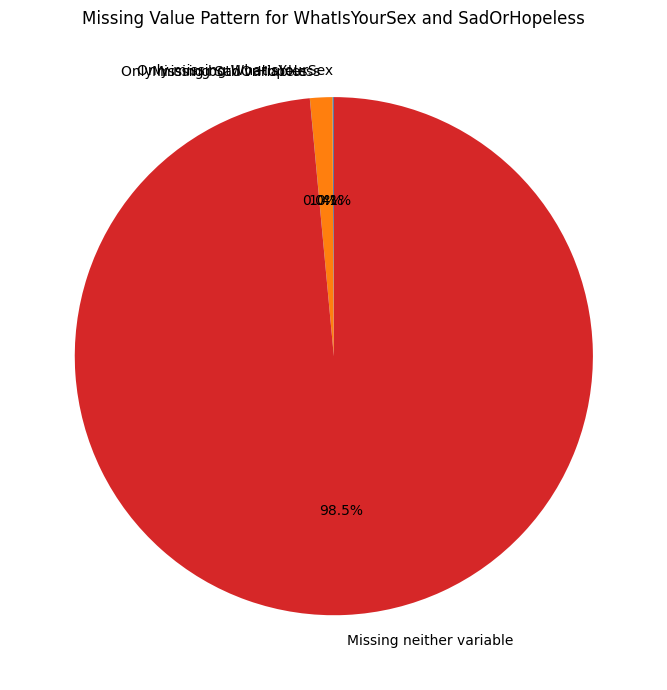

In [33]:
# Pie chart for missing value categories
plt.figure(figsize=(7, 7))

plt.pie(
    missing_summary["count"],
    labels=missing_summary["missing_category"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Missing Value Pattern for WhatIsYourSex and SadOrHopeless")
plt.tight_layout()

plt.savefig(
    fig_dir / "cycle3_missing_value_pie_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


## 7. Clean Missing Values and Recode Variables

Cleaning rule:

- Keep only records with non-missing values for both variables.
- Recode `WhatIsYourSex`: `1 = Female`, `0 = Male`.
- Recode `SadOrHopeless`: `1 = Yes`, `0 = No`.
- Remove invalid codes after recoding, if any exist.


In [34]:
# Keep only records with neither variable missing
df_clean = df_selected.loc[missing_neither].copy()

print("Before cleaning:", df_selected.shape)
print("After removing missing values:", df_clean.shape)

# Recode WhatIsYourSex
# Original: 1 = Female, 2 = Male
# New:      1 = Female, 0 = Male
df_clean["WhatIsYourSex"] = df_clean["WhatIsYourSex"].map({
    1: 1,
    2: 0
})

# Recode SadOrHopeless
# Original: 1 = Yes, 2 = No
# New:      1 = Yes, 0 = No
df_clean["SadOrHopeless"] = df_clean["SadOrHopeless"].map({
    1: 1,
    2: 0
})

# Remove invalid codes after recoding
# If any value was not 1 or 2 originally, map() changes it to NaN.
df_clean = df_clean.dropna(subset=["WhatIsYourSex", "SadOrHopeless"]).copy()

# Convert recoded variables to integer type
df_clean["WhatIsYourSex"] = df_clean["WhatIsYourSex"].astype(int)
df_clean["SadOrHopeless"] = df_clean["SadOrHopeless"].astype(int)

print("After recoding and removing invalid codes:", df_clean.shape)


Before cleaning: (14041, 2)
After removing missing values: (13833, 2)
After recoding and removing invalid codes: (13833, 2)


## 8. Check Recoded Data

This step confirms that the cleaned variables only contain the expected binary values.


In [35]:
print("Recode check: WhatIsYourSex")
print("1 = Female, 0 = Male")
display(df_clean["WhatIsYourSex"].value_counts(dropna=False).sort_index())

print("\nRecode check: SadOrHopeless")
print("1 = Yes, 0 = No")
display(df_clean["SadOrHopeless"].value_counts(dropna=False).sort_index())

print("\nFirst 5 rows of cleaned data:")
display(df_clean.head())


Recode check: WhatIsYourSex
1 = Female, 0 = Male


WhatIsYourSex
0    6893
1    6940
Name: count, dtype: int64


Recode check: SadOrHopeless
1 = Yes, 0 = No


SadOrHopeless
0    9686
1    4147
Name: count, dtype: int64


First 5 rows of cleaned data:


,WhatIsYourSex,SadOrHopeless
0,0,1
1,0,0
2,0,1
3,1,1
4,1,1


## 9. Save Cleaned Data

The cleaned dataset is saved in `data/processed/`.  
This file will be used for the later descriptive comparison and two-proportion z-test.


In [36]:
# Save cleaned and recoded data
cleaned_output_path = processed_dir / "cycle3_selected_variables.csv"

df_clean.to_csv(cleaned_output_path, index=False)

print("Cleaned data saved to:")
print(cleaned_output_path)

print("\nOutput columns:")
print(df_clean.columns.tolist())


Cleaned data saved to:
..\data\processed\cycle3_selected_variables.csv

Output columns:
['WhatIsYourSex', 'SadOrHopeless']


## 10. Notebook Output Summary

This notebook creates the following files:

| Output file | Purpose |
|---|---|
| `../outputs/tables/cycle3_missing_value_summary.csv` | Missing-value summary table |
| `../outputs/figures/cycle3_missing_value_pie_chart.png` | Missing-value pie chart |
| `../data/processed/cycle3_selected_variables.csv` | Cleaned and recoded dataset for Question 3 |

The next notebook can use `cycle3_selected_variables.csv` to complete:

1. group summary table,  
2. proportion comparison plot,  
3. confidence interval for the difference in proportions,  
4. two-proportion z-test,  
5. final interpretation.
